In [1]:

import torch, argparse, os, time, sys, shutil, yaml
import util
from data import SinogramDataset
import numpy as np
import logging
# from util import init_weights, pos_embd_gen, random_masking
# import util
from torch.utils.data import DataLoader
# from utils import init_weights, pos_embd_gen, random_masking
import matplotlib.pyplot as plt




In [2]:
import torch, sys, os
import numpy as np
from transformer import Block

sys.path.insert(1, os.path.join(sys.path[0], '..'))
from util import init_weights, pos_embd_gen, random_masking

class SinoTxEnc(torch.nn.Module):
    def __init__(self, seqlen, in_dim, params):
        super().__init__()
        self.seqlen = seqlen
        self.in_dim = in_dim

        mdl_cfg = params['model']
        self.enc_emb_dim = mdl_cfg['enc_emb_dim']
        self.mask_ratio  = mdl_cfg['mask_ratio']
        self.cls_token   = torch.nn.Parameter(torch.zeros(1, 1, self.enc_emb_dim), requires_grad=True)
        self.enc_pos_emb = torch.nn.Parameter(torch.zeros(1, self.seqlen+1, self.enc_emb_dim), requires_grad=False)
        self.enc_proj    = torch.nn.Conv2d(1, self.enc_emb_dim, kernel_size=(1, self.in_dim), bias=True)
        
        self.enc_blocks  = torch.nn.ModuleList([
            Block(self.enc_emb_dim, mdl_cfg['enc_nhead'], mlp_ratio=4, qkv_bias=True, \
                  norm_layer=torch.nn.LayerNorm) for i in range(mdl_cfg['enc_nlayer'])])
        self.enc_norm = torch.nn.LayerNorm(self.enc_emb_dim)

        self.initialize_weights()
    
    def initialize_weights(self):
        # initialize (and freeze) pos_embed by sin-cos embedding
        enc_pos_emb = pos_embd_gen(self.seqlen, self.enc_emb_dim, cls_token=True)
        self.enc_pos_emb.data.copy_(torch.from_numpy(enc_pos_emb).float().unsqueeze(0))

        # initialize proj like nn.Linear (instead of nn.Conv2d)
        w = self.enc_proj.weight.data
        torch.nn.init.xavier_uniform_(w.view([w.shape[0], -1]))

        torch.nn.init.normal_(self.cls_token,  std=.02)

        # initialize nn.Linear and nn.LayerNorm
        self.apply(init_weights)

    def forward(self, x, mask_ratio=None):
        # overwrite init at run time
        if mask_ratio is not None:
            self.mask_ratio = mask_ratio 

        # print(self.mask_ratio) # 0.8
        # print(x.shape)  # [batchsize,1,180,256]
        # print(self.enc_proj(x).shape)
        # print(self.enc_proj(x).flatten(2).shape)
        _emb = self.enc_proj(x).flatten(2).transpose(1, 2) # [batachsize,180,512]

        # print(self.enc_pos_emb.shape) # [1, 181, 512]
        # print(self.enc_pos_emb[:, 1:, :].shape) # [1, 180, 512]
        # add pos embed w/o cls token
        _tmp = _emb + self.enc_pos_emb[:, 1:, :] # [batchsize,180,512]

        # masking: length -> length * mask_ratio
        _tmp, mask, ids_restore = random_masking(_tmp, self.mask_ratio)
        # _tmp, mask, ids_restore = uniform_masking(_tmp, self.mask_ratio)
        # _tmp, mask, ids_restore = missing_wedge_mask(_tmp, self.mask_ratio)
        # print(_tmp.shape,mask.shape,ids_restore.shape) [batchsize,180*0.8=35,]
        # append cls token
        cls_token  = self.cls_token + self.enc_pos_emb[:, :1, :]
        cls_tokens = cls_token.expand(_tmp.shape[0], -1, -1)
        _tmp = torch.cat((cls_tokens, _tmp), dim=1)

        for blk in self.enc_blocks:
            _tmp = blk(_tmp)
        _tmp = self.enc_norm(_tmp)
        
        return _tmp, mask, ids_restore

class SinoTxDec(torch.nn.Module):
    def __init__(self, seqlen, out_dim, params):
        super().__init__()
        self.seqlen = seqlen
        self.out_dim = out_dim

        mdl_cfg = params['model']
        self.dec_emb_dim = mdl_cfg['dec_emb_dim']
        self.enc_emb_dim = mdl_cfg['enc_emb_dim']

        self.dec_proj    = torch.nn.Conv2d(1, self.dec_emb_dim, kernel_size=(1, self.enc_emb_dim), bias=True)
        self.mask_token  = torch.nn.Parameter(torch.randn(1, 1, self.dec_emb_dim), requires_grad=True)
        self.dec_pos_emb = torch.nn.Parameter(torch.zeros(1, self.seqlen+1, self.dec_emb_dim), requires_grad=False)

        self.dec_blocks  = torch.nn.ModuleList([
            Block(self.dec_emb_dim, mdl_cfg['dec_nhead'], mlp_ratio=4, qkv_bias=True, \
                  norm_layer=torch.nn.LayerNorm) for i in range(mdl_cfg['dec_nlayer'])])
        self.dec_norm = torch.nn.LayerNorm(self.dec_emb_dim)
        
        self.dec_pred = torch.nn.Linear(self.dec_emb_dim, self.out_dim, bias=True) 
        self.initialize_weights()

    def initialize_weights(self):
        # initialize (and freeze) pos_embed by sin-cos embedding
        dec_pos_emb = pos_embd_gen(self.seqlen, self.dec_emb_dim, cls_token=True)
        self.dec_pos_emb.data.copy_(torch.from_numpy(dec_pos_emb).float().unsqueeze(0))

        # initialize proj like nn.Linear (instead of nn.Conv2d)
        w = self.dec_proj.weight.data
        torch.nn.init.xavier_uniform_(w.view([w.shape[0], -1]))

        torch.nn.init.normal_(self.mask_token, std=.02)

        # initialize nn.Linear and nn.LayerNorm
        self.apply(init_weights)

    def forward(self, x, ids_restore):
        # embed tokens
        # print(x.shape)
        x = self.dec_proj(x[:,None]).flatten(2).transpose(1, 2)
        # print(x.shape)

        # append mask tokens to sequence
        mask_tokens = self.mask_token.repeat(x.shape[0], ids_restore.shape[1] + 1 - x.shape[1], 1)
        # print(mask_tokens.shape)
        # print(x.shape)
        x_ = torch.cat([x[:, 1:, :], mask_tokens], dim=1)  # no cls token
        x_ = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).repeat(1, 1, x.shape[2]))  # unshuffle
        x  = torch.cat([x[:, :1, :], x_], dim=1)  # append cls token
        # add pos embed
        x = x + self.dec_pos_emb

        # apply Transformer blocks
        for blk in self.dec_blocks:
            x = blk(x)
        x = self.dec_norm(x)

        # predictor projection
        x = self.dec_pred(x)

        # remove cls token
        x = x[:, 1:, :]

        return x

class SinoTx(torch.nn.Module):
    def __init__(self, seqlen, in_dim, params):
        super().__init__()
        self.encoder = SinoTxEnc(seqlen, in_dim=in_dim, params=params)
        self.decoder = SinoTxDec(seqlen, out_dim=in_dim, params=params)

    def forward_loss(self, target, pred, mask):
        loss = (pred - target) ** 2

        # loss = loss.mean(dim=-1)  # [N, L], mean loss per patch
        # loss = (loss * mask).sum() / mask.sum()  # mean loss on removed angles
        # print("loss",loss.shape)
        loss = loss.mean()
        # print("loss",loss.shape)
        return loss

    def forward(self, imgs, mask_ratio=None):
        if mask_ratio is not None:
            self.encoder.mask_ratio = mask_ratio
        # print("encoder begin")
        # print("input",imgs.shape)
        latent, mask, ids_restore = self.encoder.forward(imgs)
        # print("encoder end")
        # print("decoder begin")
        # print("latent",latent.shape)
        # print("mask",mask.shape)
        # print("ids_restore",ids_restore.shape)
        pred = self.decoder.forward(latent, ids_restore)  # [N, L, D]
        # print("output",pred.shape)
        # print("decoder end")
        loss = self.forward_loss(imgs[:,0], pred, mask)
        # print("loss",loss.shape)
        return loss, pred, mask

In [3]:
cfg = "config/simu.yaml"
params = yaml.load(open(cfg, 'r'), Loader=yaml.CLoader)
logging.info("Init validation dataset ...")
valid_ds = SinogramDataset(ifn=params['dataset']['vh5'], params=params)
valid_dl = DataLoader(valid_ds, batch_size=params['train']['mbsz'], num_workers=4, \
                            prefetch_factor=params['train']['mbsz'], pin_memory=True, \
                            drop_last=False, shuffle=False)
logging.info(f"%d samples, shape {valid_ds.shape},  will be used for validation" % (len(valid_ds), ))

model_path= "/home/zhyh/TomoTx/SinoTx/debug-itrOut/mdl-ep00200.pth"
model = SinoTx(seqlen=valid_ds.seqlen, in_dim=valid_ds.cdim, params=params).cuda()
checkpoint = torch.load(model_path)
model.load_state_dict(checkpoint)
# model = model.eval()

<All keys matched successfully>

torch.Size([20, 1, 180, 256])
(20, 180, 256)
torch.Size([20, 180, 256])
(20, 180, 256)
(180, 256) (180, 256)


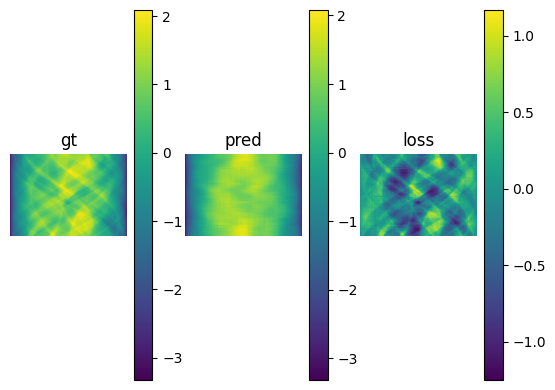

[[-3.3276515 -2.6470728 -2.3397145 ... -2.120173  -2.3397145 -2.6470728]
 [-3.288035  -2.6518598 -2.3477204 ... -2.1264458 -2.3477204 -2.6518598]
 [-3.2601383 -2.6770327 -2.3652177 ... -2.1314802 -2.3652177 -2.6770327]
 ...
 [-3.242476  -2.7091386 -2.3493712 ... -2.1150558 -2.3493712 -2.7091386]
 [-3.2601383 -2.6770327 -2.3652177 ... -2.1314802 -2.3652177 -2.6770327]
 [-3.288035  -2.6518598 -2.3477204 ... -2.1264458 -2.3477204 -2.6518598]]


: 

In [7]:
for imgs_val in valid_dl:
        print(imgs_val.shape)
        a = imgs_val[:,0].cpu().numpy()
        print(a.shape)
        with torch.no_grad():
            _vloss, _vpred, _vmask = model.forward(imgs_val.cuda())
            print(_vpred.shape)
            b = _vpred.cpu().numpy()
            print(b.shape)

pic_a = a[1,:,:]
pic_b = b[1,:,:]
print(pic_a.shape,pic_b.shape)


plt.subplot(1, 3, 1)
plt.imshow(pic_a)
plt.axis("off")
plt.colorbar()
plt.title('gt')

plt.subplot(1, 3, 2)
plt.imshow(pic_b)
plt.axis("off")
plt.colorbar()
plt.title('pred')

plt.subplot(1, 3, 3)
plt.imshow(pic_a-pic_b)
plt.axis("off")
plt.colorbar()
plt.title('loss')


plt.show()

print(pic_a)
            

        
        